In [1]:
import pickle

with open("dataset/resplan_numeric_100.pkl", "rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edge_index = data["edge_index"]
edge_attr = data["edge_attr"]
text = data["text"]

print(len(nodes))
print(nodes[0].shape)
print(edge_attr[0].shape)

100
(17, 11)
(32, 10)


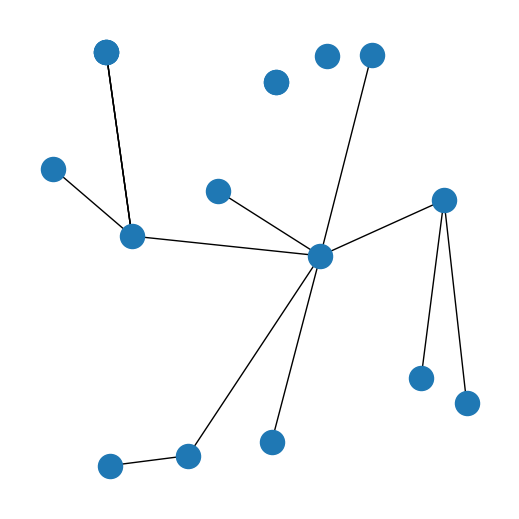

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
i=0
x=nodes[i]
edge_index_1=edge_index[i]
G=nx.Graph()


# node positions from centroid features
cx = x[:,7]
cy = x[:,8]

for n in range(len(x)):
    G.add_node(n, pos=(cx[n], cy[n]))

for s,d in edge_index_1.T:
    G.add_edge(int(s), int(d))

pos = nx.get_node_attributes(G,"pos")

plt.figure(figsize=(5,5))
nx.draw(G,pos,node_size=300)
plt.gca().invert_yaxis()
plt.show()

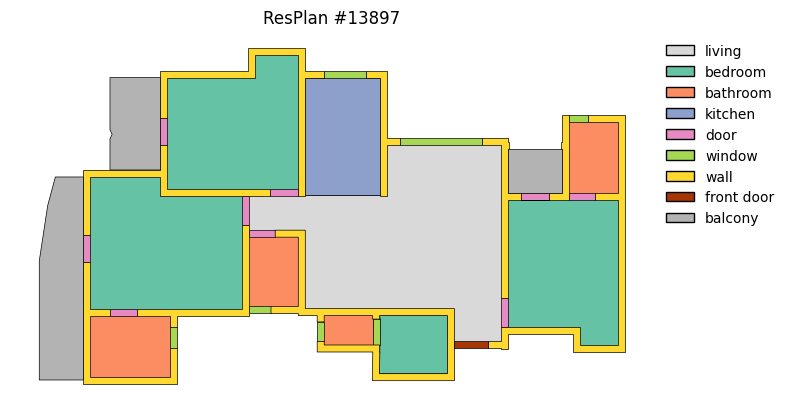

In [3]:
from dataset.resplan_utils import plot_plan

# load numeric subset
with open("dataset/resplan_numeric_100.pkl","rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edges = data["edge_index"]
plan_idx = data["plan_idx"]

i = 0
orig_idx = plan_idx[i]

# load ResPlan
with open("dataset/ResPlan.pkl","rb") as f:
    plans = pickle.load(f)

plan = plans[orig_idx]

# show floorplan
plot_plan(plan, title=f"ResPlan #{orig_idx}")
plt.show()

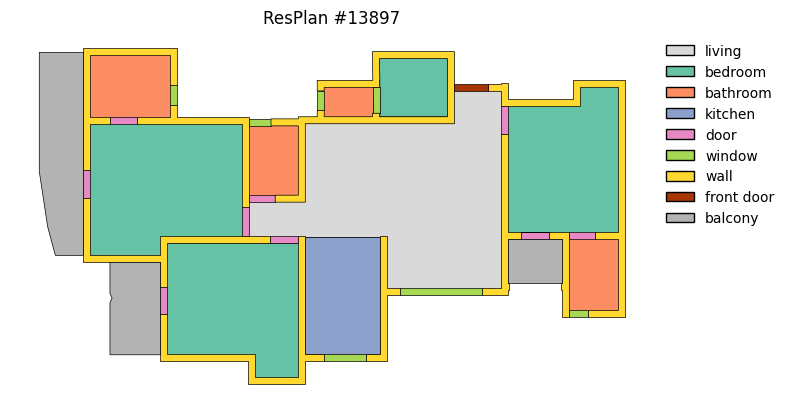

In [ ]:
# Draw floorplan first
plot_plan(plan, title=f"ResPlan #{orig_idx}")
ax = plt.gca()

# Floorplan bounds
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
xmin, xmax = min(x0, x1), max(x0, x1)
ymin, ymax = min(y0, y1), max(y0, y1)

# Map normalized node coords (0..1) into floorplan axis coords
pos_plan = {
    k: (
        xmin + float(v[0]) * (xmax - xmin),
        ymin + float(v[1]) * (ymax - ymin),
    )
    for k, v in pos.items()
}

# Overlay graph
edge_coll = nx.draw_networkx_edges(
    G, pos_plan, ax=ax, edge_color="red", width=2.0, alpha=0.9
)
node_coll = nx.draw_networkx_nodes(
    G, pos_plan, ax=ax, node_color="yellow", edgecolors="black", node_size=120, alpha=1.0
)

# Keep graph above floorplan
if edge_coll is not None:
    edge_coll.set_zorder(10)
if node_coll is not None:
    node_coll.set_zorder(11)

# Preserve view/aspect/orientation
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()